# Importación de librerías:
## decisionTreeClassifier: modelo de árbol de decisión
## plot_tree: para visualizar gráficamente el árbol
## classification_report, confusion_matrix: métricas de evaluación
## train_test_split: divide los datos en entrenamiento y validación
## sklearn.tree: visualizacion del arbol en formato contextual
## matplotlib.pyplot: visualización del árbol
## pandas: importación y manipulación de datos
## joblid: grabar el modelo

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import export_text
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
import joblib
import os
import json

In [2]:
data = pd.read_csv("reviews_22052025_2400.csv")

In [3]:
data.columns

Index(['review_id', 'user_id', 'business_id', 'review_count_user', 'text',
       'average_stars_user', 'yelping_days', 'useful', 'funny', 'cool', 'fans',
       'Cluster'],
      dtype='object')

In [4]:
data.rename(columns={'classification': 'Cluster'}, inplace=True)

# Se convierte Genuine en 1 y Fake en 0

In [5]:
data['Cluster'] = data['Cluster'].replace({'Genuine': 1, 'Fake': 0}).astype(int)
print(data['Cluster'].unique())

[1 0]


In [6]:
data.columns

Index(['review_id', 'user_id', 'business_id', 'review_count_user', 'text',
       'average_stars_user', 'yelping_days', 'useful', 'funny', 'cool', 'fans',
       'Cluster'],
      dtype='object')

In [7]:
data.shape

(1850, 12)

In [8]:
user_columns = ['review_count_user', 'average_stars_user', 'yelping_days',
    'useful', 'funny', 'cool', 'fans', 'Cluster']

In [9]:
user_cluster_df = data.copy()

In [10]:
user_cluster_df.columns

Index(['review_id', 'user_id', 'business_id', 'review_count_user', 'text',
       'average_stars_user', 'yelping_days', 'useful', 'funny', 'cool', 'fans',
       'Cluster'],
      dtype='object')

In [11]:
user_cluster_df.shape

(1850, 12)

## Cuantos usuarios estan presentes en los dos cluster

In [12]:
clusters_por_usuario = user_cluster_df.groupby('user_id')['Cluster'].nunique()
usuarios_varios_clusters = clusters_por_usuario[clusters_por_usuario > 1].index
print("Usuarios en varios cluster: " , len(usuarios_varios_clusters))

Usuarios en varios cluster:  3


## Eliminamos usuarios que estan en los dos cluster

In [13]:
# Eliminamos lo usuarios en varios cluster
user_cluster_df_filtrado = user_cluster_df[~user_cluster_df['user_id'].isin(usuarios_varios_clusters)]

In [14]:
user_cluster_df_filtrado.shape

(1844, 12)

In [15]:
# Verificar
print(user_cluster_df_filtrado['user_id'].nunique())
print(user_cluster_df_filtrado['Cluster'].value_counts())

1839
Cluster
0    975
1    869
Name: count, dtype: int64


In [16]:
user_cluster_df_filtrado.columns

Index(['review_id', 'user_id', 'business_id', 'review_count_user', 'text',
       'average_stars_user', 'yelping_days', 'useful', 'funny', 'cool', 'fans',
       'Cluster'],
      dtype='object')

In [17]:
features = user_cluster_df_filtrado[['review_count_user', 'average_stars_user', 'yelping_days',
    'useful', 'funny', 'cool', 'fans', 'Cluster']]

In [18]:
print(features.isna().sum())

review_count_user     0
average_stars_user    0
yelping_days          0
useful                0
funny                 0
cool                  0
fans                  0
Cluster               0
dtype: int64


In [19]:
X = features[['review_count_user', 'average_stars_user', 'yelping_days',
    'useful', 'funny', 'cool', 'fans']]
y = features['Cluster']

# División para entrenamiento y validación
## se divide 70% para entrenamiento y 30% para validación

In [20]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Entrenamiento
## se realiza un arbol de decisión con profundidad 3

In [21]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

# Validación
## se crea el modelo para predecir los cluster

In [22]:
y_pred = tree_model.predict(X_val)

# Evaluación de las metricas
## se imprime la precisión, recall y F1-score

In [23]:
print("Reporte de Clasificación (Validación):")
print(classification_report(y_val, y_pred))

Reporte de Clasificación (Validación):
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       293
           1       0.66      0.69      0.68       261

    accuracy                           0.69       554
   macro avg       0.69      0.69      0.69       554
weighted avg       0.69      0.69      0.69       554



# Table de confusión
## se imprime la tabla de confusión

In [24]:
print("Matriz de Confusión:")
print(confusion_matrix(y_val, y_pred))

Matriz de Confusión:
[[201  92]
 [ 81 180]]


# Visualizacion del arbol de decisión
## se imprime el arbol de decisión

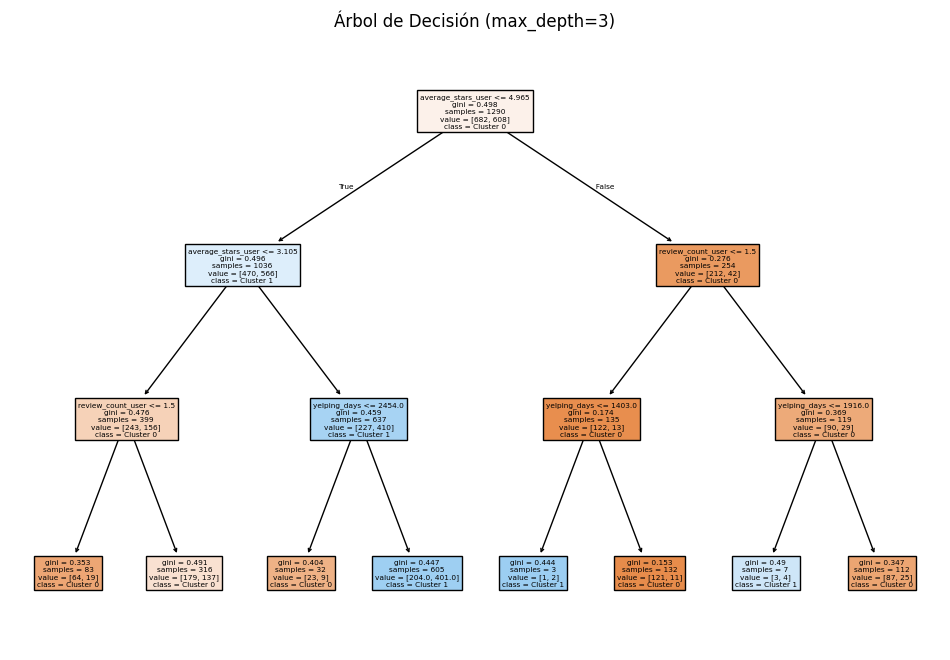

In [25]:
plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=['Cluster 0', 'Cluster 1'], filled=True)
plt.title("Árbol de Decisión (max_depth=3)")
plt.show()


# Visualizacion del arbol de decisión en formato textual

In [26]:
rules_text = export_text(tree_model, feature_names=list(X.columns))
print(rules_text)

|--- average_stars_user <= 4.96
|   |--- average_stars_user <= 3.10
|   |   |--- review_count_user <= 1.50
|   |   |   |--- class: 0
|   |   |--- review_count_user >  1.50
|   |   |   |--- class: 0
|   |--- average_stars_user >  3.10
|   |   |--- yelping_days <= 2454.00
|   |   |   |--- class: 0
|   |   |--- yelping_days >  2454.00
|   |   |   |--- class: 1
|--- average_stars_user >  4.96
|   |--- review_count_user <= 1.50
|   |   |--- yelping_days <= 1403.00
|   |   |   |--- class: 1
|   |   |--- yelping_days >  1403.00
|   |   |   |--- class: 0
|   |--- review_count_user >  1.50
|   |   |--- yelping_days <= 1916.00
|   |   |   |--- class: 1
|   |   |--- yelping_days >  1916.00
|   |   |   |--- class: 0



# Grabación de las reglas en un fichero .txt

In [27]:
with open("reglas_arbol_decision.txt", "w", encoding="utf-8") as f:
    f.write(rules_text)

In [35]:
# Guardar el modelo en un archivo
joblib.dump(tree_model, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

In [36]:
import pandas as pd
import joblib

# 1. Cargar el modelo guardado
loaded_model = joblib.load('decision_tree_model.pkl')

# 2. Cargar nuevo dataset
new_data = pd.read_csv('reviews_22052025_100.csv')

# 3. Seleccionar las mismas columnas de características
X_new = new_data[['review_count_user', 'average_stars_user', 'yelping_days',
                  'useful', 'funny', 'cool', 'fans']]

# 4. Predecir con el modelo cargado
y_new_pred = loaded_model.predict(X_new)

# 5. Añadir la predicción al dataframe
new_data['predictions'] = y_new_pred

# 6. Guardar resultados en nuevo CSV
new_data.to_csv('reviews_22052025_100_with_predictions.csv', index=False)

print("Predicciones realizadas y guardadas en 'reviews_22052025_100_with_predictions.csv'")


Predicciones realizadas y guardadas en 'reviews_22052025_100_with_predictions.csv'


In [38]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix

# 1. Cargar el modelo guardado
loaded_model = joblib.load('decision_tree_model.pkl')

# 2. Cargar nuevo dataset
new_data = pd.read_csv('reviews_22052025_100.csv')

# 3. Seleccionar las mismas columnas de características
X_new = new_data[['review_count_user', 'average_stars_user', 'yelping_days',
                  'useful', 'funny', 'cool', 'fans']]

# 4. Predecir con el modelo cargado
y_new_pred = loaded_model.predict(X_new)

# 5. Añadir la predicción al dataframe
new_data['predictions'] = y_new_pred

# 6. Obtener etiquetas reales
y_true = new_data['Cluster']

# 7. Generar reporte de clasificación
print("Reporte de Clasificación (Validación):")
print(classification_report(y_true, y_new_pred, digits=2))

# 8. Generar matriz de confusión
print("Matriz de Confusión:")
print(confusion_matrix(y_true, y_new_pred))



Reporte de Clasificación (Validación):
              precision    recall  f1-score   support

           0       0.72      0.63      0.67        52
           1       0.65      0.73      0.69        48

    accuracy                           0.68       100
   macro avg       0.68      0.68      0.68       100
weighted avg       0.68      0.68      0.68       100

Matriz de Confusión:
[[33 19]
 [13 35]]
